In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("diyabet.csv")

In [ ]:
df


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


<Axes: >

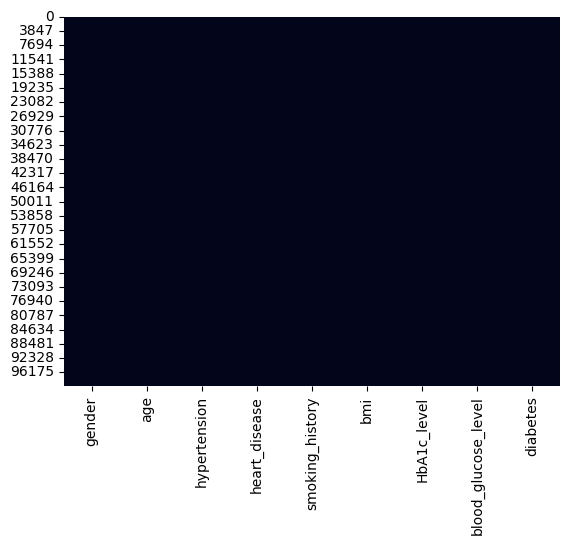

In [ ]:
sns.heatmap(df.isnull(),cbar=False)

In [ ]:
import pandas as pd

df = pd.read_csv('diyabet.csv')

df = df.drop_duplicates()

df['gender'] = df['gender'].astype(str).str.strip().str.lower()

df = df[df['gender'] != 'other']

df['gender'] = df['gender'].map({'male': 0, 'female': 1})


df['smoking_history'] = df['smoking_history'].fillna('No Info')
df['smoking_history'] = df['smoking_history'].astype(str).str.strip().str.lower()

smoking_map = {
    'no info': 0,
    'never': 1,
    'current': 2,
    'not current': 3,
    'ever': 4,
    'former': 5
}
df['smoking_history_numeric'] = df['smoking_history'].map(smoking_map)


print(f"Remaining Total Number of Lines: {len(df)}")
print("-" * 30)
print("Gender Unique Values:", df['gender'].unique())
print("Smoking Unique Values:", df['smoking_history_numeric'].unique())

Remaining Total Number of Lines: 96128
------------------------------
Gender Unique Values: [1 0]
Smoking Unique Values: [1 0 2 5 4 3]


In [ ]:

df['smoking_history'] = df['smoking_history'].fillna('No Info')

df['smoking_history'] = df['smoking_history'].astype(str).str.strip().str.lower()

smoking_map = {
    'no info': 0,
    'never': 1,
    'current': 2,
    'not current': 3,
    'ever': 4,
    'former': 5
}

df['smoking_history_numeric'] = df['smoking_history'].map(smoking_map)


print("Unique Values:", df['smoking_history_numeric'].unique())
print(df[['smoking_history', 'smoking_history_numeric']].head())

Unique Values: [1 0 2 5 4 3]
  smoking_history  smoking_history_numeric
0           never                        1
1         no info                        0
2           never                        1
3         current                        2
4         current                        2


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df[num_cols].head())

        age       bmi  HbA1c_level  blood_glucose_level
0  1.700709 -0.314941     0.994547             0.043558
1  0.543261 -0.000214     0.994547            -1.423041
2 -0.614187 -0.000214     0.155949             0.483538
3 -0.258049 -0.572042    -0.496294             0.410208
4  1.522640 -1.061124    -0.682649             0.410208


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


if 'smoking_history' in df.columns and df['smoking_history'].dtype == 'object':
    df.drop(columns=['smoking_history'], inplace=True)


if 'smoking_history_numeric' in df.columns:
    df.rename(columns={'smoking_history_numeric': 'smoking_history'}, inplace=True)

In [ ]:
df.head(15)

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history
0,1,1.700709,0,1,-0.314941,0.994547,0.043558,0,1
1,1,0.543261,0,0,-0.000214,0.994547,-1.423041,0,0
2,0,-0.614187,0,0,-0.000214,0.155949,0.483538,0,1
3,1,-0.258049,0,0,-0.572042,-0.496294,0.410208,0,2
4,0,1.522640,1,1,-1.061124,-0.682649,0.410208,0,2
5,1,-0.970325,0,0,-0.000214,0.994547,-1.300824,0,1
6,1,0.098088,0,0,-1.183764,0.901370,1.510157,1,1
7,1,1.656192,0,0,-0.511461,0.155949,-1.300824,0,0
8,0,0.009054,0,0,0.933623,-0.682649,0.165775,0,1
9,1,-0.436118,0,0,-0.000214,-0.496294,-0.934175,0,1


In [ ]:

numeric_df = df.select_dtypes(include=['float64', 'int64'])


summary_table = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Std Dev': numeric_df.std()
})


print(summary_table.round(4))

                       Mean  Median    Mode  Std Dev
gender               0.5842  1.0000  1.0000   0.4929
age                  0.0000  0.0536  1.7007   1.0000
hypertension         0.0776  0.0000  0.0000   0.2676
heart_disease        0.0408  0.0000  0.0000   0.1979
bmi                  0.0000 -0.0002 -0.0002   1.0000
HbA1c_level         -0.0000  0.2491  0.9945   1.0000
blood_glucose_level  0.0000  0.0436  0.5080   1.0000
diabetes             0.0882  0.0000  0.0000   0.2836
smoking_history      1.3976  1.0000  1.0000   1.5704


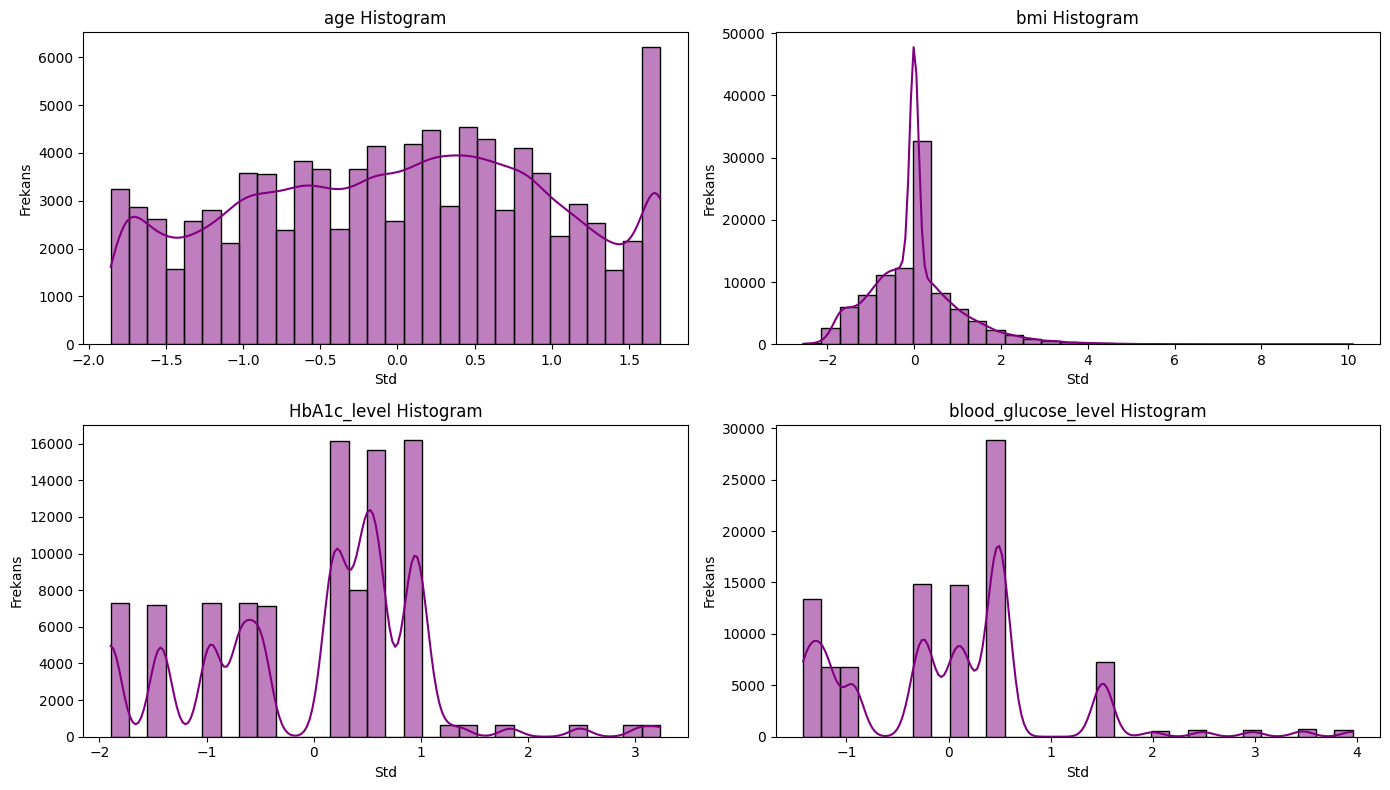

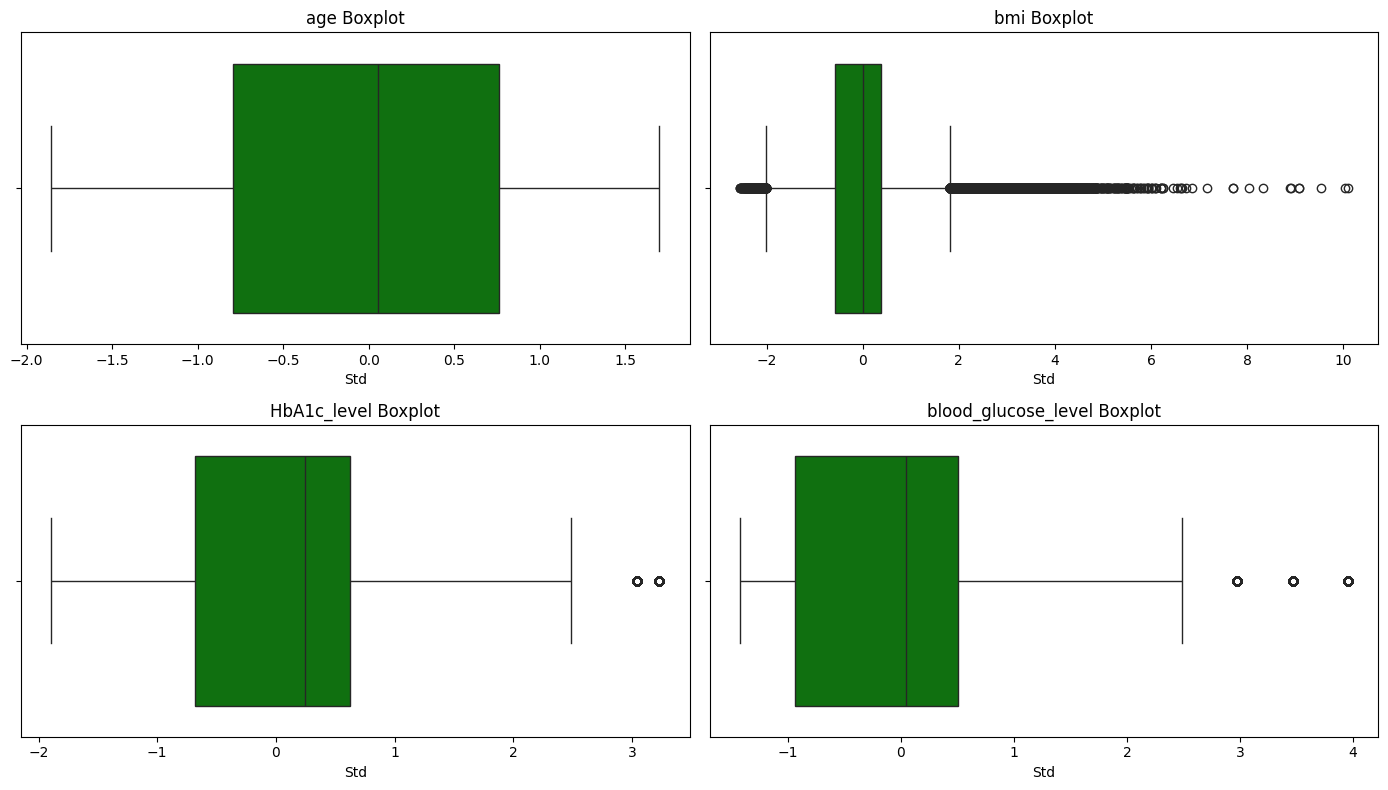

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


plt.figure(figsize=(14, 8))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, color='purple', bins=30)
    plt.title(f'{col} Histogram')
    plt.xlabel('Std')
    plt.ylabel('Frekans')
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col], color='green')
    plt.title(f'{col} Boxplot')
    plt.xlabel('Std')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, ' Correlation Heatmap')

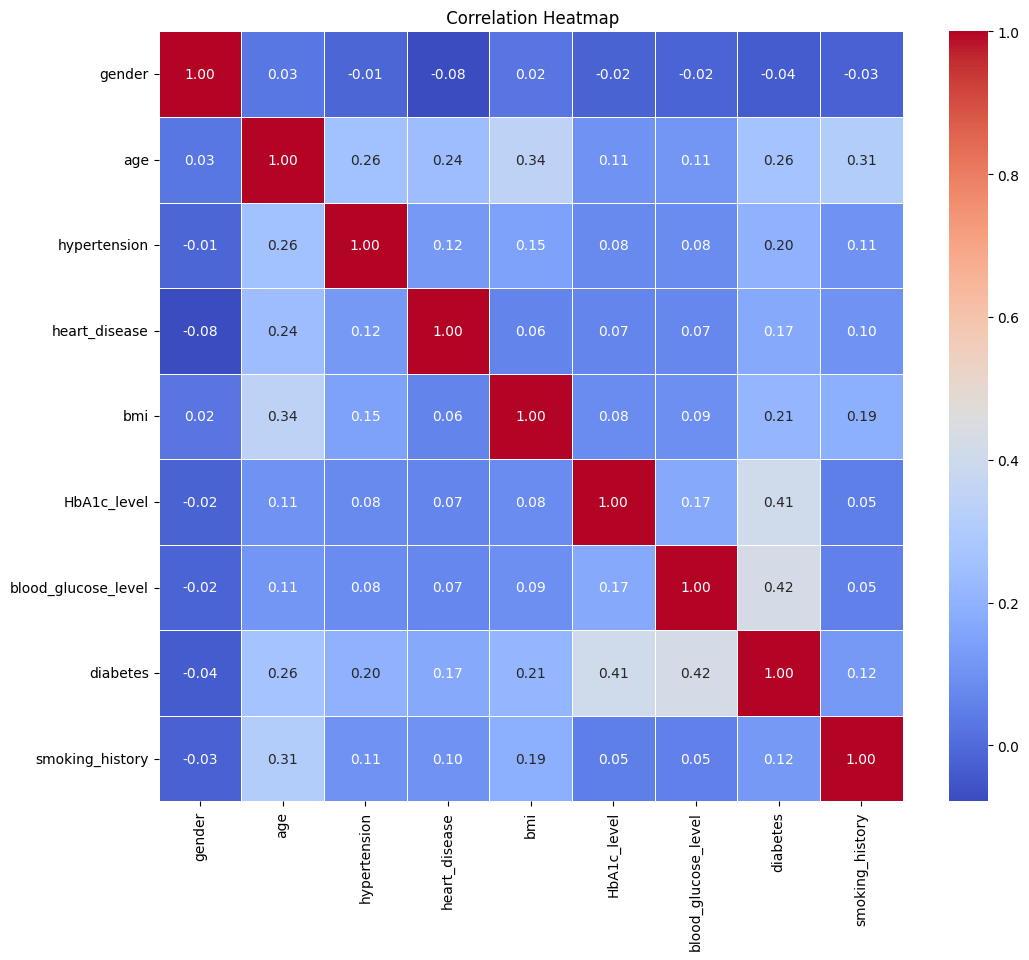

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(' Correlation Heatmap')


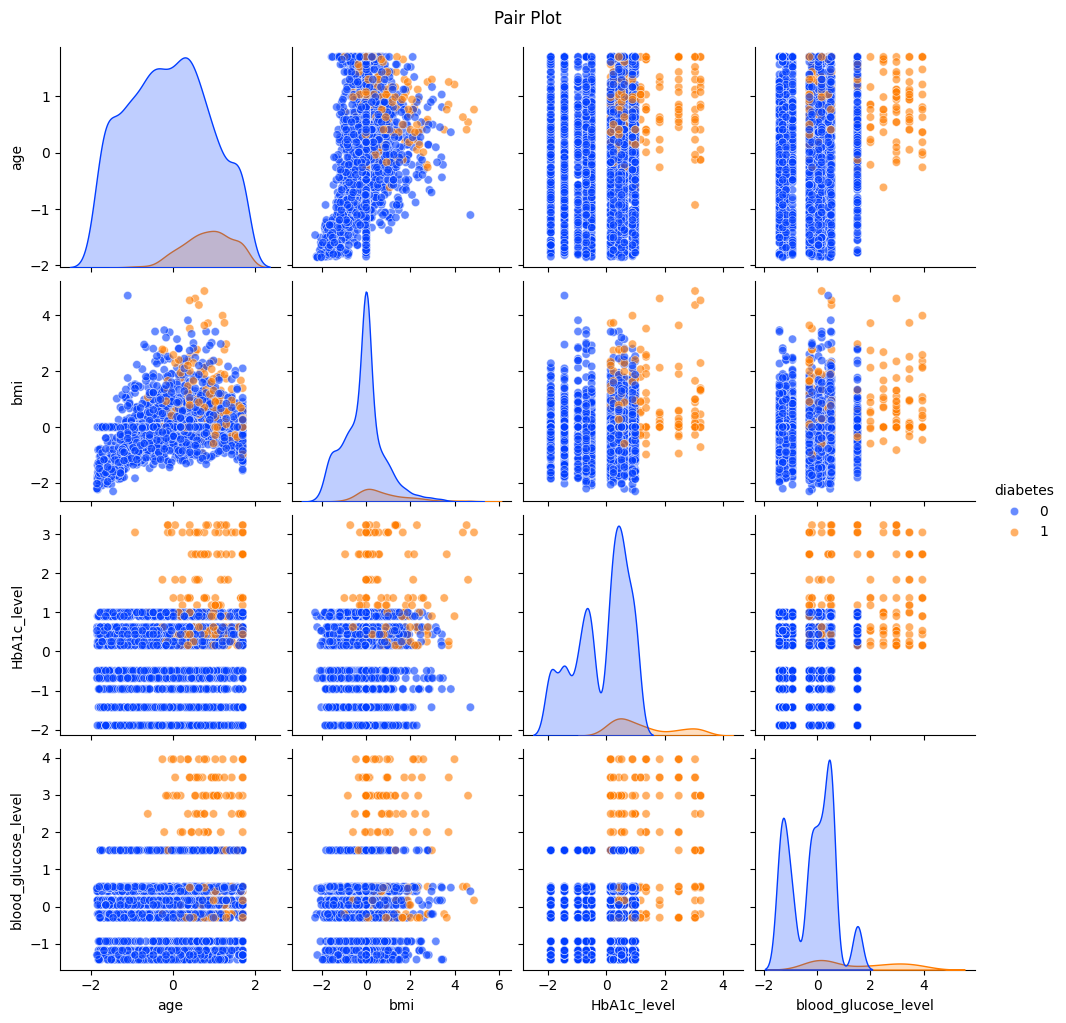

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sample = df.sample(n=2000, random_state=42)

sns.pairplot(df_sample,
             vars=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'],
             hue='diabetes',
             palette='bright',
             plot_kws={'alpha': 0.6})

plt.suptitle('Pair Plot', y=1.02)
plt.show()

/tmp/ipython-input-1182614054.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], x='smoking_history', data=df, palette='viridis')
/tmp/ipython-input-1182614054.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(risk_labels)


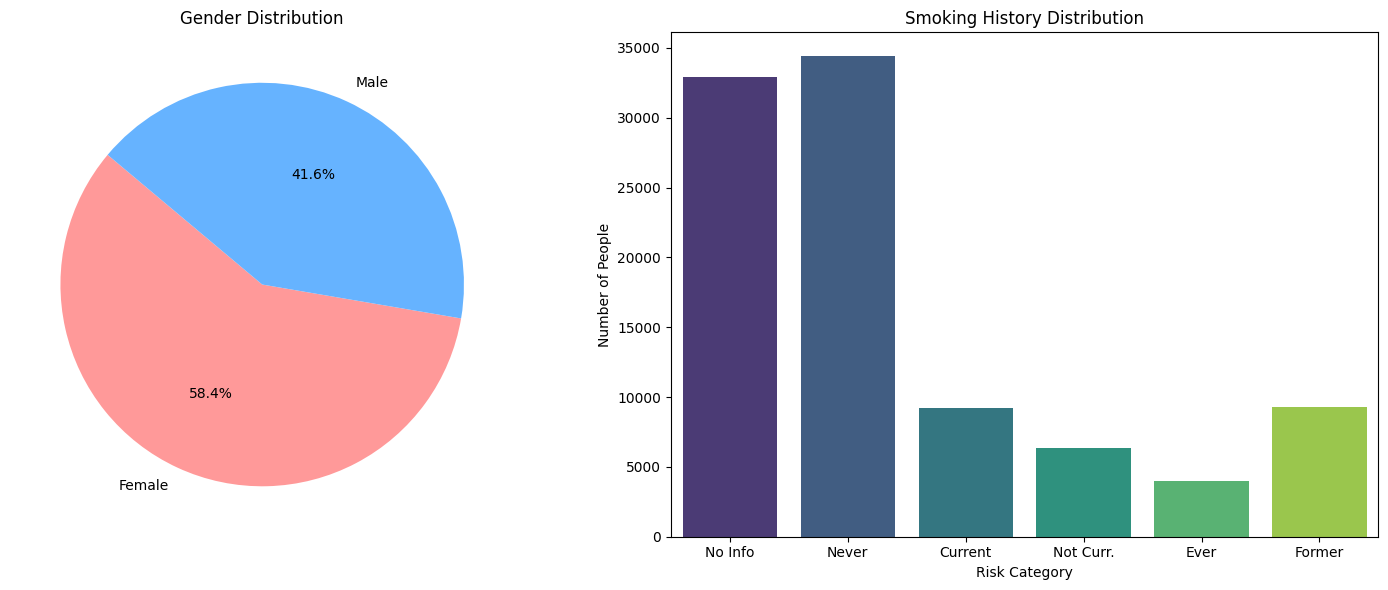

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

gender_counts = df['gender'].value_counts()

counts = [df[df['gender']==1].shape[0], df[df['gender']==0].shape[0]]
labels = ['Female', 'Male']
colors = ['#ff9999', '#66b3ff']

axes[0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
axes[0].set_title('Gender Distribution')

sns.countplot(ax=axes[1], x='smoking_history', data=df, palette='viridis')

axes[1].set_title('Smoking History Distribution')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Number of People')

risk_labels = ['No Info', 'Never', 'Current', 'Not Curr.', 'Ever', 'Former']
axes[1].set_xticklabels(risk_labels)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('diyabet.csv')
df = df.drop_duplicates()
df = df[df['gender'] != 'Other']
df['gender'] = df['gender'].astype(str).str.strip().str.lower().map({'female': 1, 'male': 0})
df['smoking_history'] = df['smoking_history'].fillna('No Info').astype(str).str.strip().str.lower()
smoking_map = {'no info': 0, 'never': 1, 'current': 2, 'not current': 3, 'ever': 4, 'former': 5}
df['smoking_history'] = df['smoking_history'].map(smoking_map).fillna(0)


scaler = StandardScaler()
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[num_cols] = scaler.fit_transform(df[num_cols])

y = df['diabetes']
X = df.drop(columns=['diabetes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Veri Hazır: Eğitim {X_train.shape}, Test {X_test.shape}")

Veri Hazır: Eğitim (76902, 8), Test (19226, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

print("=== BASELINE RESULTS (DEFAULT PARAMETERS) ===")
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

baseline_df = pd.DataFrame(baseline_results).round(4)
print(baseline_df)

=== BASELINE RESULTS (DEFAULT PARAMETERS) ===
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.9583     0.8565  0.6333    0.7281
1        Decision Tree    0.9481     0.6922  0.7412    0.7158
2        Random Forest    0.9694     0.9390  0.6987    0.8012


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

print("=== HYPERPARAMETER TUNING RESULTS ===")


log_params = {'C': [0.1, 1, 10], 'class_weight': ['balanced', None]}
grid_log = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                        log_params,
                        cv=3,           # <--- Cross Validation (3-Fold)
                        scoring='f1',   # <--- Metric Used (F1-Score)
                        n_jobs=-1)
grid_log.fit(X_train, y_train)


dt_params = {'max_depth': [5, 10, None], 'class_weight': ['balanced', None]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params,
                       cv=3,            # <--- Cross Validation (3-Fold)
                       scoring='f1',
                       n_jobs=-1)
grid_dt.fit(X_train, y_train)


rf_params = {'n_estimators': [100, 200], 'max_depth': [10, None], 'class_weight': ['balanced']}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params,
                       cv=3,            # <--- Cross Validation (3-Fold)
                       scoring='f1',    # <--- Optimization Goals
                       n_jobs=-1)
grid_rf.fit(X_train, y_train)


print(f"LogReg Best: {grid_log.best_params_}")
print(f"DecTree Best: {grid_dt.best_params_}")
print(f"RanForest Best: {grid_rf.best_params_}")


tuning_comparison = []


baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}


for model in baseline_models.values():
    model.fit(X_train, y_train)

models_to_compare = [
    ('Logistic Regression', baseline_models['Logistic Regression'], grid_log.best_estimator_),
    ('Decision Tree', baseline_models['Decision Tree'], grid_dt.best_estimator_),
    ('Random Forest', baseline_models['Random Forest'], grid_rf.best_estimator_)
]

for name, default_model, tuned_model in models_to_compare:
    y_def = default_model.predict(X_test)
    y_tuned = tuned_model.predict(X_test)

    tuning_comparison.append({
        'Model': name,
        'Acc (Before)': accuracy_score(y_test, y_def),
        'Acc (After)': accuracy_score(y_test, y_tuned),
        'Precision (Before)': precision_score(y_test, y_def),
        'Precision (After)': precision_score(y_test, y_tuned),
        'Recall (Before)': recall_score(y_test, y_def),
        'Recall (After)': recall_score(y_test, y_tuned),
        'F1 (Before)': f1_score(y_test, y_def),
        'F1 (After)': f1_score(y_test, y_tuned)
    })

tuning_df = pd.DataFrame(tuning_comparison).round(4)
print("\n[ ENSEMBLE MODELS: BEFORE vs AFTER TUNING ]")
print(tuning_df)

=== HYPERPARAMETER TUNING RESULTS ===
LogReg Best: {'C': 10, 'class_weight': None}
DecTree Best: {'class_weight': None, 'max_depth': 5}
RanForest Best: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}

[ ENSEMBLE MODELS: BEFORE vs AFTER TUNING ]
                 Model  Acc (Before)  Acc (After)  Precision (Before)  \
0  Logistic Regression        0.9583       0.9582              0.8565   
1        Decision Tree        0.9481       0.9718              0.6922   
2        Random Forest        0.9694       0.9695              0.9390   

   Precision (After)  Recall (Before)  Recall (After)  F1 (Before)  F1 (After)  
0             0.8558           0.6333          0.6333       0.7281      0.7279  
1             1.0000           0.7412          0.6798       0.7158      0.8094  
2             0.9447           0.6987          0.6946       0.8012      0.8005  


In [ ]:
print("=== FINAL FULL PERFORMANCE & OVERFITTING CHECK ===")

best_models = {
    'Logistic Regression': grid_log.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_
}

full_comparison = []
for name, model in best_models.items():

    y_tr_pred = model.predict(X_train)

    y_te_pred = model.predict(X_test)

    full_comparison.append({
        'Model': name,
        'Acc Train': accuracy_score(y_train, y_tr_pred),
        'Acc Test': accuracy_score(y_test, y_te_pred),
        'F1 Train': f1_score(y_train, y_tr_pred),
        'F1 Test': f1_score(y_test, y_te_pred),
        'Rec Train': recall_score(y_train, y_tr_pred),
        'Rec Test': recall_score(y_test, y_te_pred)
    })

full_df = pd.DataFrame(full_comparison).round(4)
print("\n[ FULL OVERFITTING CHECK TABLE: TRAIN VS TEST ]")
print(full_df)

=== FINAL FULL PERFORMANCE & OVERFITTING CHECK ===

[ FULL OVERFITTING CHECK TABLE: TRAIN VS TEST ]
                 Model  Acc Train  Acc Test  F1 Train  F1 Test  Rec Train  \
0  Logistic Regression     0.9587    0.9582    0.7287   0.7279     0.6291   
1        Decision Tree     0.9705    0.9718    0.7994   0.8094     0.6658   
2        Random Forest     0.9992    0.9695    0.9954   0.8005     1.0000   

   Rec Test  
0    0.6333  
1    0.6798  
2    0.6946  



=== VISUALIZATIONS ===


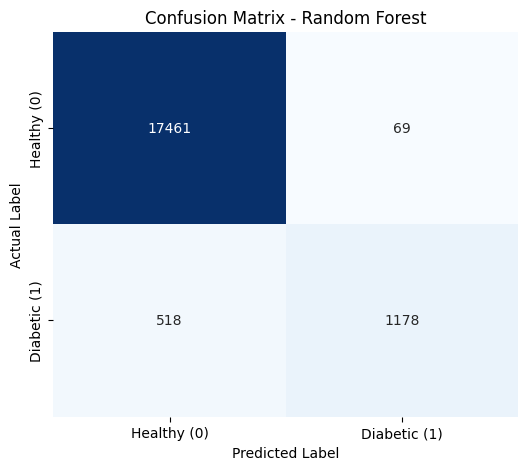

Random Forest Confusion Matrix (shown above)



/tmp/ipython-input-2077066508.py:35: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--')


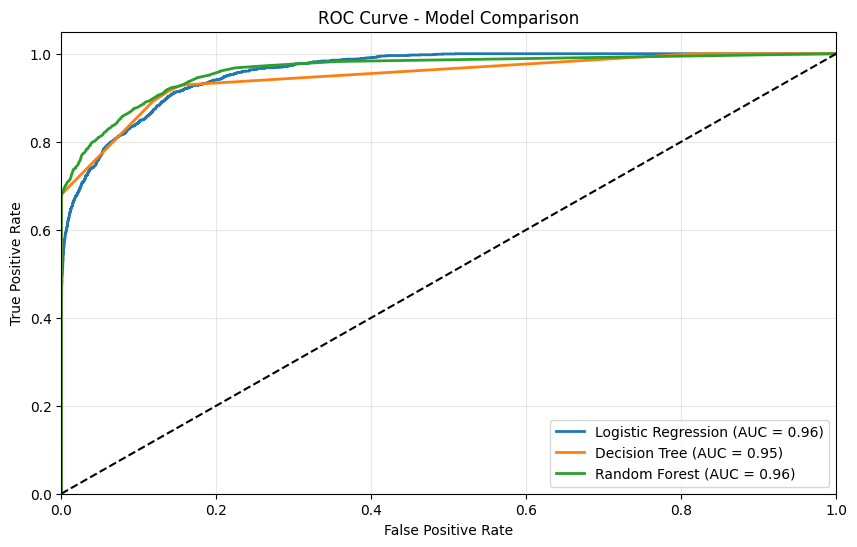

ROC Curves of Models (shown above)



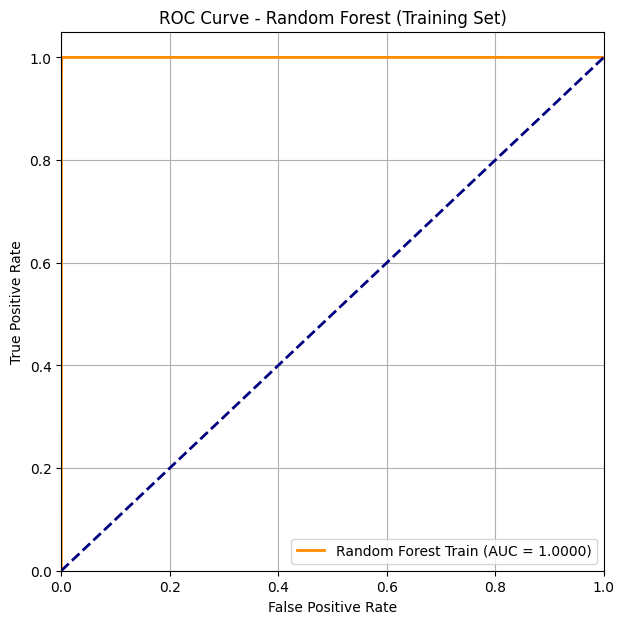

Random Forest Training AUC Score: 1.0000 (shown above)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("\n=== VISUALIZATIONS ===")


rf_model_final = best_models['Random Forest']
y_pred_rf_final = rf_model_final.predict(X_test)

plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf_final)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy (0)', 'Diabetic (1)'],
            yticklabels=['Healthy (0)', 'Diabetic (1)'])

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()
print("Random Forest Confusion Matrix (shown above)\n")



plt.figure(figsize=(10, 6))

for name, model in best_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()
print("ROC Curves of Models (shown above)\n")


y_proba_train_rf = rf_model_final.predict_proba(X_train)[:, 1]
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_proba_train_rf)
roc_auc_train_rf = auc(fpr_train_rf, tpr_train_rf)

plt.figure(figsize=(7, 7))
plt.plot(fpr_train_rf, tpr_train_rf, color='darkorange', lw=2,
         label=f'Random Forest Train (AUC = {roc_auc_train_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Training Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f"Random Forest Training AUC Score: {roc_auc_train_rf:.4f} (shown above)\n")

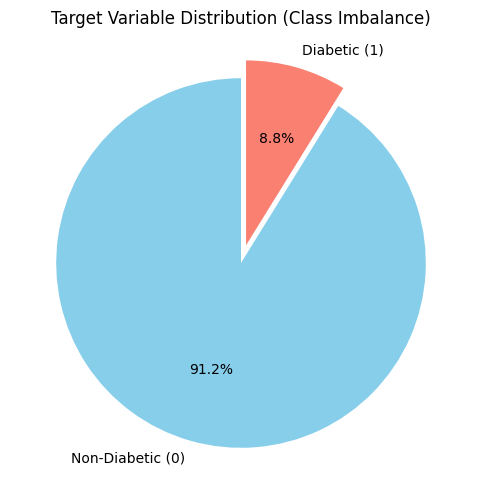

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

y.value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'], labels=['Non-Diabetic (0)', 'Diabetic (1)'], startangle=90, explode=(0, 0.1))
plt.title('Target Variable Distribution (Class Imbalance)')
plt.ylabel('')
plt.show()

/tmp/ipython-input-937831930.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


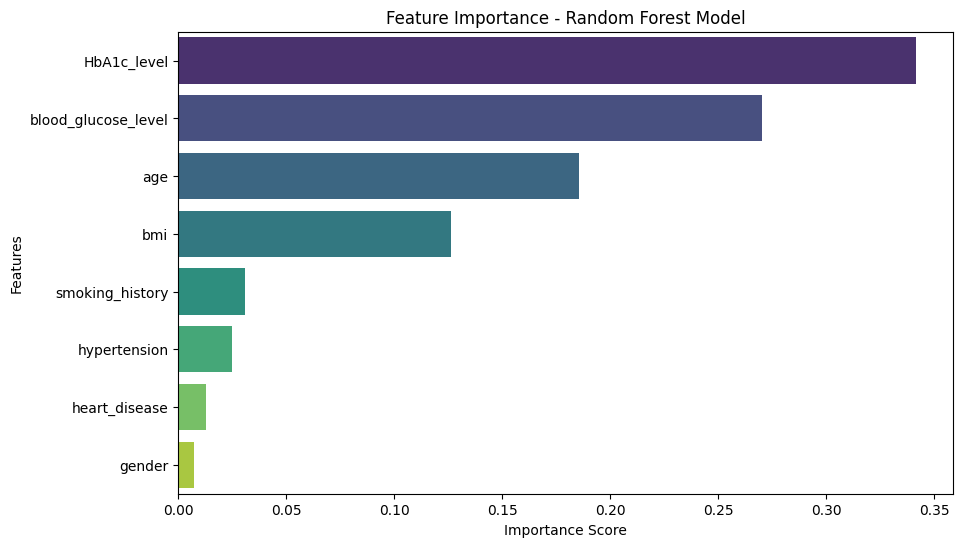

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


rf_final = grid_rf.best_estimator_
importances = rf_final.feature_importances_
feature_names = X.columns


feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("--- MODEL 3: KNN RESULTS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn):.4f}")

--- MODEL 3: KNN RESULTS ---
Accuracy:  0.9586
Precision: 0.8750
Recall:    0.6191
F1-Score:  0.7251


In [ ]:

models_ensemble_default = {
    'Model 4: Random Forest': RandomForestClassifier(random_state=42),
    'Model 5: Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Model 6: AdaBoost': AdaBoostClassifier(random_state=42)
}


results_default = []

for name, model in models_ensemble_default.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_default.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })


df_default = pd.DataFrame(results_default)
print("--- BEFORE TUNING (DEFAULT) RESULTS ---")
print(df_default)

--- BEFORE TUNING (DEFAULT) RESULTS ---
                        Model  Accuracy  Precision    Recall  F1-Score
0      Model 4: Random Forest  0.969416   0.938986  0.698703  0.801217
1  Model 5: Gradient Boosting  0.971393   0.978297  0.691038  0.809952
2           Model 6: AdaBoost  0.971757   1.000000  0.679835  0.809407


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


models_ensemble = {
    'Model 4: Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Model 5: Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'Model 6: AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
}


results_ens = []

for name, model in models_ensemble.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_ens.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })


df_results_ens = pd.DataFrame(results_ens)
print(df_results_ens)

                        Model  Accuracy  Precision    Recall  F1-Score
0      Model 4: Random Forest  0.969468   0.944667  0.694575  0.800544
1  Model 5: Gradient Boosting  0.971393   0.978297  0.691038  0.809952
2           Model 6: AdaBoost  0.971757   1.000000  0.679835  0.809407


/tmp/ipython-input-2116487465.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[i], palette='viridis')
/tmp/ipython-input-2116487465.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[i], palette='viridis')
/tmp/ipython-input-2116487465.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[i], palette='viridis')


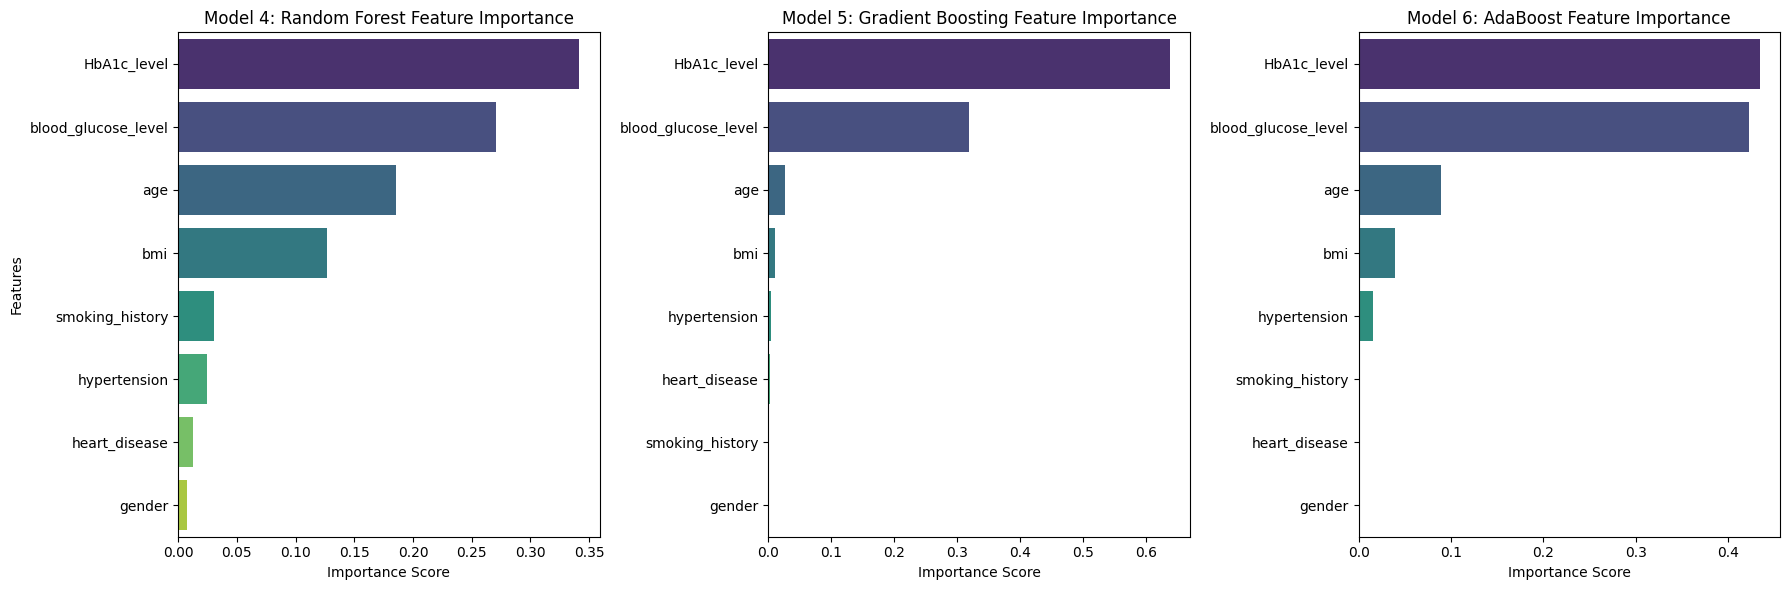

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42).fit(X_train, y_train)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42).fit(X_train, y_train)
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42).fit(X_train, y_train)


models = [
    ('Model 4: Random Forest', models_ensemble['Model 4: Random Forest']),
    ('Model 5: Gradient Boosting', models_ensemble['Model 5: Gradient Boosting']),
    ('Model 6: AdaBoost', models_ensemble['Model 6: AdaBoost'])
]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model) in enumerate(models):

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    feature_names = X.columns


    sns.barplot(x=importances[indices], y=feature_names[indices], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{name} Feature Importance')
    axes[i].set_xlabel('Importance Score')
    axes[i].set_ylabel('Features' if i == 0 else '')

plt.tight_layout()
plt.show()